In [1]:
import warnings
warnings.filterwarnings("ignore")

import os
import sys
import time
import json
import numpy as np
import pandas as pd
import geopandas as gpd
import pickle as pkl
import networkx as nx
import matplotlib.pyplot as plt
import pyomo.environ as pe

import visualizations as vis

import good
from good.reload import deep_reload

This nodebook shows an example of how to run GOOD for a pre-built graph. In this case the aggregated California example graph is loaded and run for 7 days with results plotted. The same is done with flexible base loads in the second example.

The first step is to load the graph. Let's use the WECC example.

In [2]:
# graph = good.graph.graph_from_json('Examples/California.json')
graph = good.graph.graph_from_json('C:\\Users\\ht9\\PycharmProjects\\good_model\\Examples\\California.json')

graph.nodes

NodeView(('WEC_BANC', 'WEC_CALN', 'WEC_LADW', 'WEC_SDGE', 'WECC_IID', 'WECC_SCE'))

First we will run the grid with custom policies

In [3]:
'''
Loading graph and policies
'''
deep_reload(good)

graph = good.graph.graph_from_json('Examples/California.json')

policies = good.utilities.read_json('Examples/policies.json')

In [4]:
'''
Building from graph for 7 day run - 06/01:00:00:00 - 06/07:23:59:59
'''
deep_reload(good)

kw = {
    'verbose': True,
    'steps': (6 * 32 * 24, 6 * 32 * 24 + 24 * 30),
    'amortization_period': 31536000,
    'shortfall_capacity': np.inf,
    'shortfall_cost': 1e3,
    'wastage_capacity': np.inf,
    'wastage_cost': 1e3,
}

network = good.optimization.network.Network(**kw).from_graph(
    graph, policies)

'''
Building the model
'''

network.build()

'''
Printing model size report
'''

network.size()

Parameters Built: 1.4852588176727295
Variables Built: 0.9126071929931641
Constraints Built: 8.446451902389526
Objective Built: 1.11879563331604


ModelSizeReport(activated = Bunch(binary_variables = 0, constraints = 863368, continuous_variables = 317724, disjunctions = 0, disjuncts = 0, integer_variables = 0, nonlinear_constraints = 0, variables = 317724), overall = Bunch(binary_variables = 0, constraints = 863368, continuous_variables = 317724, disjunctions = 0, disjuncts = 0, integer_variables = 0, nonlinear_constraints = 0, variables = 317724), warning = Bunch(unassociated_disjuncts = 0))

In [5]:
'''
Solving the model
'''
deep_reload(good)

kw = {
    'solver': {
        '_name': 'gurobi',
    },
}

network.solve(**kw)
solution = network.solution_graph()
dataframe = network.solution_dataframe(solution)

print(f'Objective Value: {pe.value(network.model.objective)}')

Problem Solved: 20.14604115486145
Solution Graph Built: 9.948323965072632
Solution DataFrame Built: 0.35527610778808594
Objective Value: 211827344.2243404


In [6]:
'''
Saving solution graph to JSON
'''

good.graph.graph_to_json(solution, 'solution.json')

In [7]:
'''
Saving solution DataFrame to CSV
'''

dataframe.to_csv('solution.csv')

In [ ]:
'''
Plotting LMPs
'''
deep_reload(vis)

fig, ax = plt.subplots(1, 1, figsize = (8, 4))

_ = vis.plot_lmps(ax, graph, solution)

In [ ]:
'''
Plotting Regional loads and generation
'''
deep_reload(vis)

fig, ax = plt.subplots(3, 1, figsize = (8, 10))

_ = vis.plot_base_loads(ax[0], graph, solution)
_ = vis.plot_total_generation(ax[1], graph, solution)
_ = vis.plot_net_generation(ax[2], graph, solution)

In [ ]:
'''
Plotting generation by type
'''
deep_reload(vis)

fig, ax = plt.subplots(1, 1, figsize = (8, 6))

_ = vis.plot_generation_by_type(ax, graph, solution)

In [ ]:
'''
Plotting generation by fuel
'''
deep_reload(vis)

fig, ax = plt.subplots(1, 1, figsize = (8, 6))

_ = vis.plot_generation_by_fuel(ax, graph, solution)

In [ ]:
'''
Plotting capex by type
'''
deep_reload(vis)

fig, ax = plt.subplots(1, 1, figsize = (8, 6))

_ = vis.plot_capex_by_type(ax, graph, solution)

Now, let's implement custom policies

In [ ]:
'''
Loading graph and policies - with no capex
'''
deep_reload(good)

graph = good.graph.graph_from_json('Examples/California.json')

policies = {
    'california_ps':{
        '_class': 'Portfolio_Standard',
        'ratio': 0.85,
        'inclusion_criteria': {
            0: "lambda a: a.get('renewable', False)",
            1: "lambda a: a.get('_class', '') != 'Store'",
            2: "lambda a: a.get('type', '') != 'load'",
            3: "lambda a: a.get('jurisdiction', '') == 'CA'"
        },
        'exclusion_criteria': {
            0: "lambda a: not a.get('renewable', False)",
            1: "lambda a: a.get('_class', '') != 'Store'",
            2: "lambda a: a.get('type', '') != 'load'",
            3: "lambda a: a.get('jurisdiction', '') == 'CA'"
        },
    },
    'california_ct': {
        '_class': 'Capacity_Target',
        'target': 70e9,
        'inclusion_criteria': {
            0: "lambda a: a.get('renewable', False)",
            1: "lambda a: a.get('_class', '') != 'Store'",
            2: "lambda a: a.get('type', '') != 'load'",
            3: "lambda a: a.get('jurisdiction', '') == 'CA'"
        },
    },
    'california_rm' : {
        '_class': 'Reserve_Margin',
        'margin': .1,
        'sign': -1,
        'demand_criteria': {
            2: "lambda a: a.get('type', '') == 'load'",
        },
        'supply_criteria': {
            1: "lambda a: a.get('_class', '') != 'Store'",
            2: "lambda a: a.get('type', '') != 'load'",
        },
    },
}

In [ ]:
'''
Building from graph for 7 day run - 06/01:00:00:00 - 06/07:23:59:59
'''
deep_reload(good)

kw = {
    'verbose': True,
    'steps': (6 * 32 * 24, 6 * 32 * 24 + 24 * 7),
    'amortization_period': 31536000,
    'shortfall_capacity': np.inf,
    'shortfall_cost': 1e3,
    'wastage_capacity': np.inf,
    'wastage_cost': 1e3,
}

network = good.optimization.network.Network(**kw).from_graph(
    graph, policies)

'''
Building the model
'''

network.build()

'''
Printing model size report
'''

network.size()

In [ ]:
'''
Solving the model
'''
deep_reload(good)

kw = {
    'solver': {
        '_name': 'cbc',
    },
}

network.solve(**kw)
solution = network.solution_graph()
dataframe = network.solution_dataframe(solution)

print(f'Objective Value: {pe.value(network.model.objective)}')

In [ ]:
'''
Plotting LMPs
'''
deep_reload(vis)

fig, ax = plt.subplots(1, 1, figsize = (8, 4))

_ = vis.plot_lmps(ax, graph, solution)

In [ ]:
'''
Plotting Regional loads and generation
'''
deep_reload(vis)

fig, ax = plt.subplots(3, 1, figsize = (8, 10))

_ = vis.plot_base_loads(ax[0], graph, solution)
_ = vis.plot_total_generation(ax[1], graph, solution)
_ = vis.plot_net_generation(ax[2], graph, solution)

In [ ]:
'''
Plotting generation by type
'''
deep_reload(vis)

fig, ax = plt.subplots(1, 1, figsize = (8, 6))

_ = vis.plot_generation_by_type(ax, graph, solution)

In [ ]:
'''
Plotting generation by fuel
'''
deep_reload(vis)

fig, ax = plt.subplots(1, 1, figsize = (8, 6))

_ = vis.plot_generation_by_fuel(ax, graph, solution)

In [ ]:
'''
Plotting capex by type
'''
deep_reload(vis)

fig, ax = plt.subplots(1, 1, figsize = (8, 6))

_ = vis.plot_capex_by_type(ax, graph, solution)

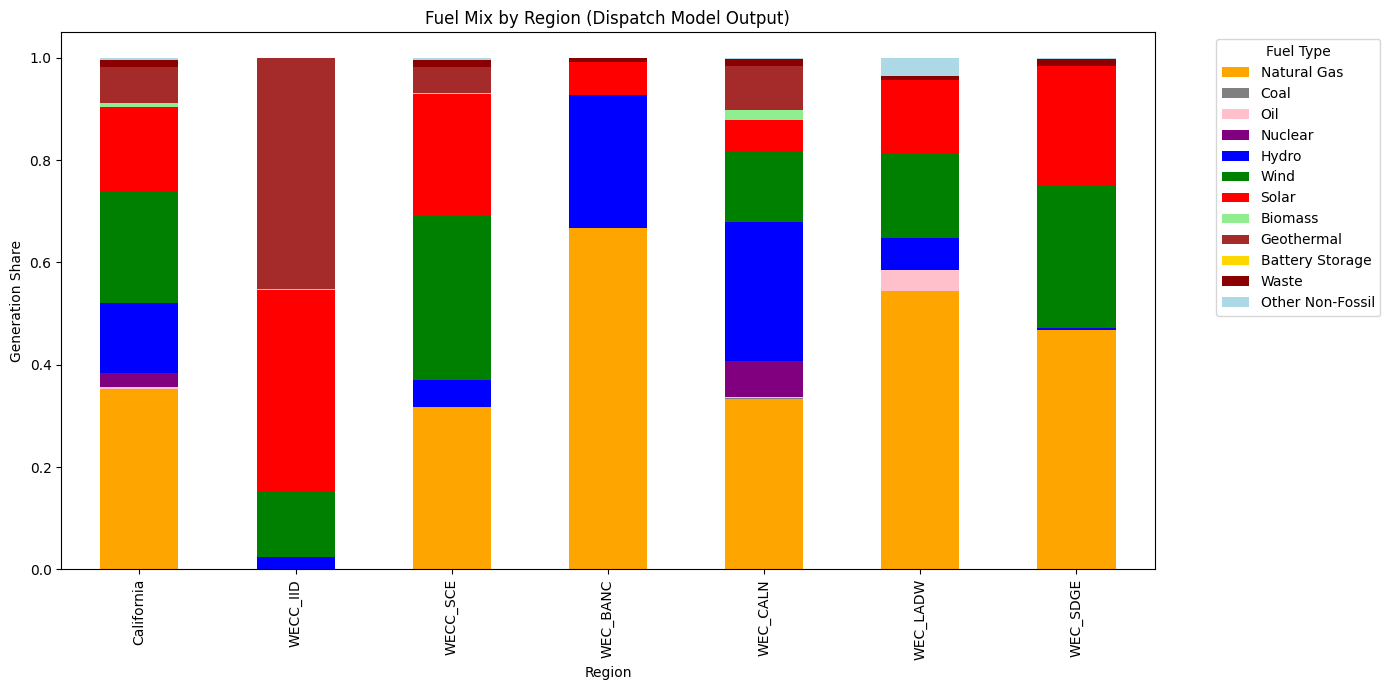

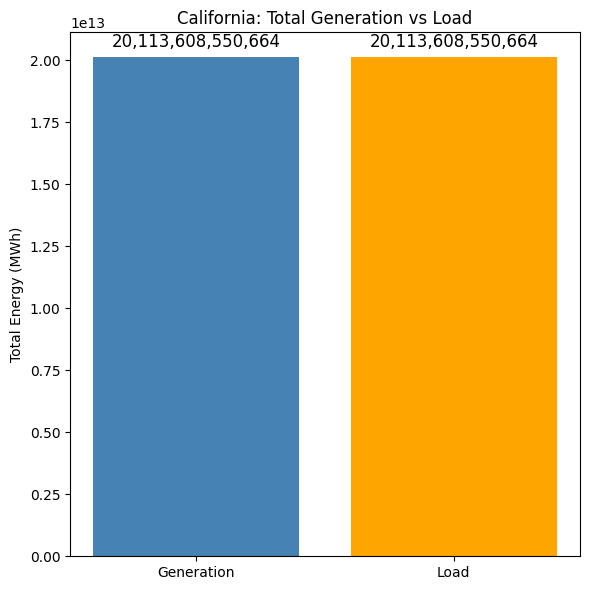

In [8]:
'''
Plotting dispatch fuel mix
'''
deep_reload(vis)
json_path = 'C:\\Users\\ht9\\PycharmProjects\\good_model\\Examples\\California.json'
good.visualization.visualization_plot.plot_dispatch_fuel_mix(dataframe, json_path)